In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df = pd.read_csv('D:\\Data Analytics\\employee_attrition\\dataset\\clean_dataset.csv')
df.head()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,salary_hike_pct,...,total_working_years,work_mode,overtime_hours_per_week,burnout_score,engagement_score,work_life_balance_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition,age_group
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,Mid Level,7365,14.1,...,15.9,Remote,2.4,1.0,9.7,7.7,True,4.8,0,Mid Career (30-39)
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,Associate,4746,7.9,...,4.0,Onsite,4.1,1.9,5.4,7.8,True,2.9,1,Early Career (21-29)
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,Entry Level,2740,12.8,...,4.0,Hybrid,3.3,5.3,6.5,7.0,True,7.2,0,Early Career (21-29)
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,Senior Level,7334,12.8,...,12.5,Hybrid,12.0,4.3,7.3,3.5,False,5.2,0,Senior Career (40-49)
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,Mid Level,9096,10.6,...,10.5,Hybrid,4.9,2.3,7.0,7.2,False,6.4,0,Mid Career (30-39)


In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,4902.0,3497.411669,1445.505213,1001.0,2242.250,3493.5,4749.75,6000.0
age,4902.0,37.115871,8.217833,21.0,31.000,37.0,43.00,64.0
monthly_income,4902.0,6990.345369,2698.098773,1500.0,4976.250,6571.0,8605.75,21609.0
salary_hike_pct,4902.0,11.514810,3.409665,0.0,9.300,11.6,13.80,22.6
years_at_company,4902.0,6.725765,3.504820,0.0,4.200,6.8,9.20,18.1
total_working_years,4902.0,11.705569,4.997990,0.0,8.325,11.9,15.10,30.4
overtime_hours_per_week,4902.0,6.828641,4.470116,0.0,3.600,5.9,9.00,34.9
burnout_score,4902.0,4.031436,1.537415,1.0,2.900,4.0,5.00,10.0
engagement_score,4902.0,6.508486,1.496846,1.0,5.500,6.5,7.60,10.0
work_life_balance_score,4902.0,6.130437,1.291034,1.0,5.300,6.2,7.00,9.9


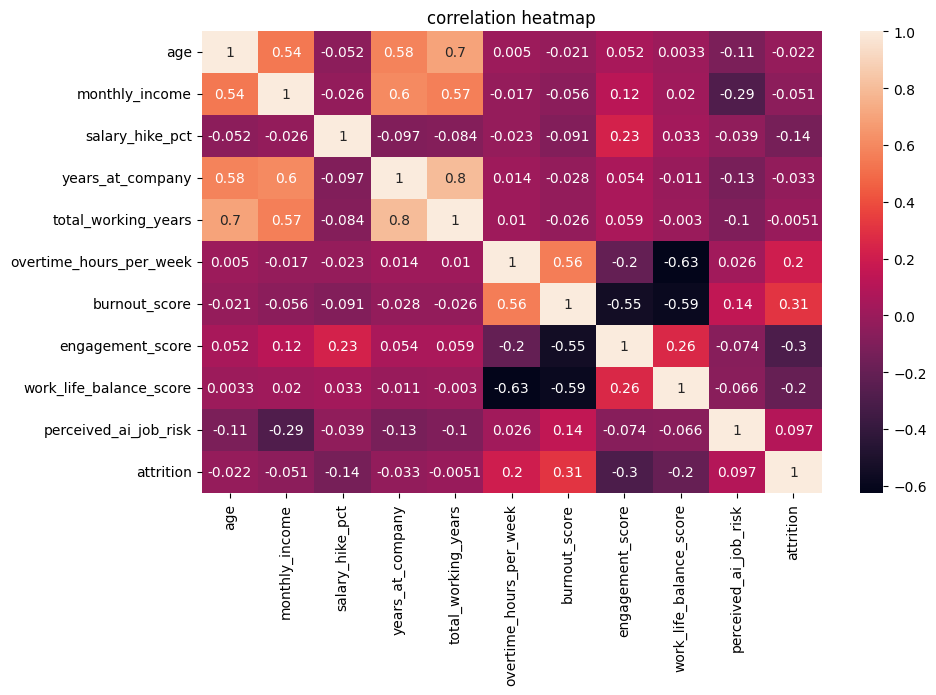

In [56]:
numeric_cols = df.select_dtypes(include=['float64' , 'int64']).drop(columns = ['employee_id'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr() , annot=True  )
plt.title("correlation heatmap")
plt.show()

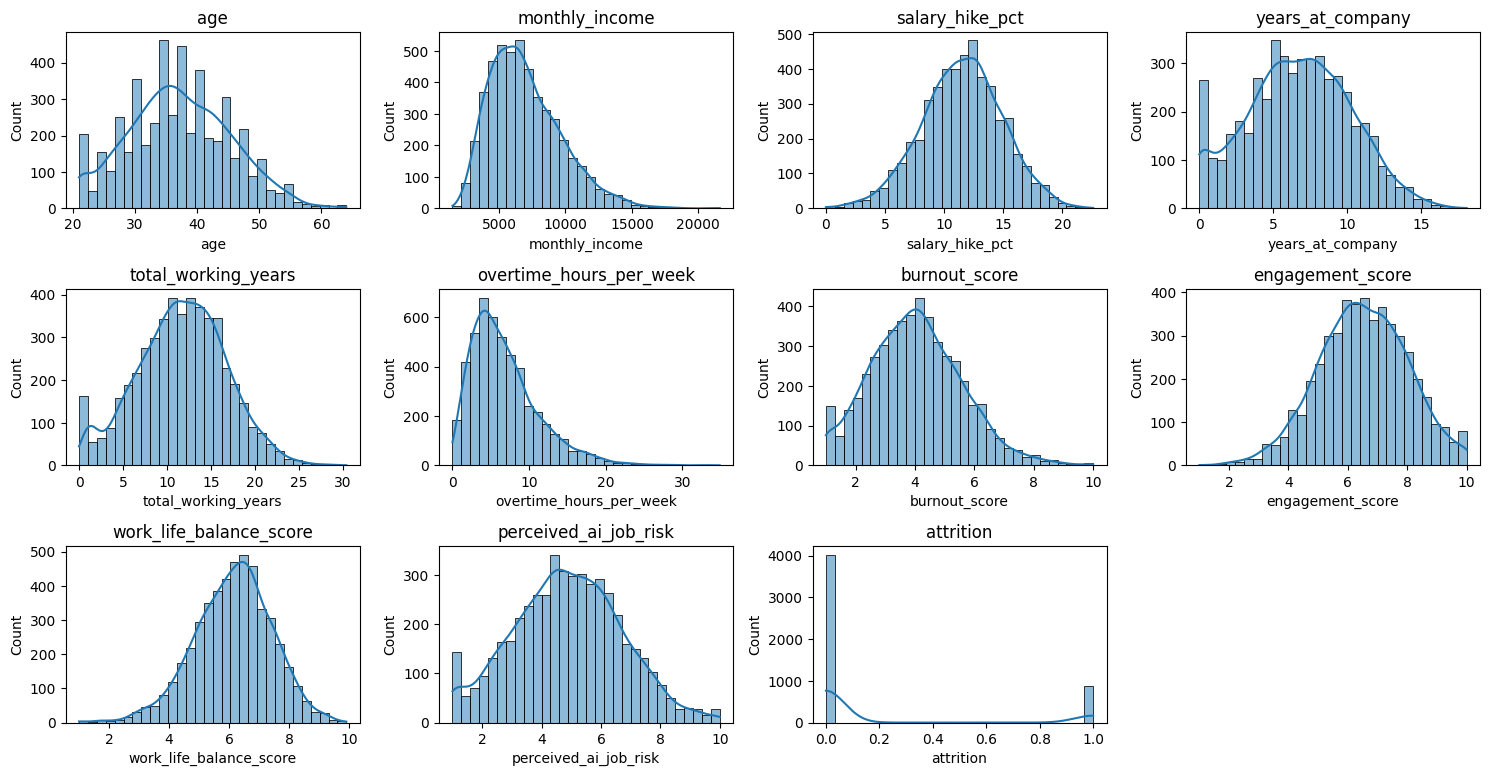

In [57]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

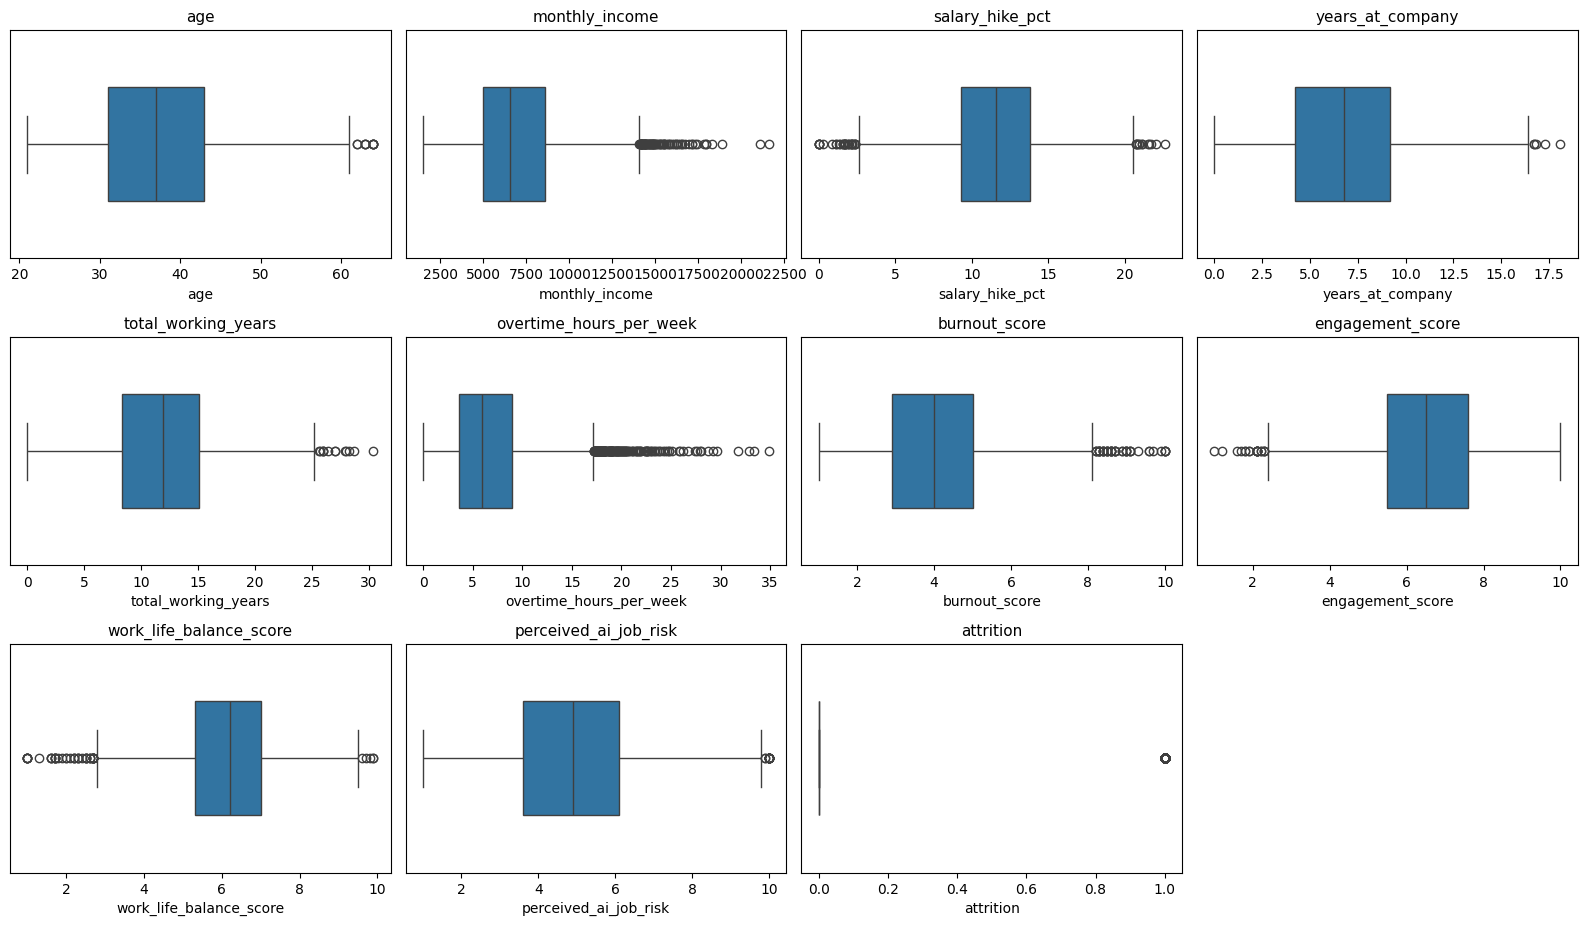

In [58]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[col],showfliers=True,width=0.5)

    plt.title(col, fontsize=11)
    plt.yticks([])

plt.tight_layout()
plt.show()

* KPI

In [61]:
total_emp = len(df)
print(f"total employee : {total_emp}")

avg_monthly_income = df['monthly_income'].mean()
print(f"avg monthly income : {avg_monthly_income.round(2)}")

total_attrition = (df['attrition'] == 1).sum()
print(f"total employee left : {total_attrition}")

total_retantion = (df['attrition'] == 0).sum()
print(f"total employee work : {total_retantion}")

attrition_rate = ((total_attrition / total_emp) * 100)
print(f"overall attrition rate : {attrition_rate.round(2)}%")
retention_rate = ((total_retantion / total_emp) * 100)
print(f"overall retration rate : {retention_rate.round(2)} %")

total employee : 4902
avg monthly income : 6990.35
total employee left : 878
total employee work : 4024
overall attrition rate : 17.91%
overall retration rate : 82.09 %


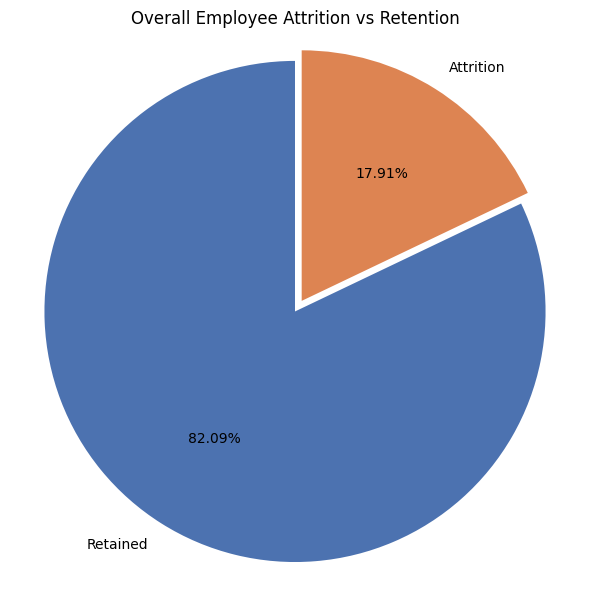

In [65]:
# Pie chart
labels = ['Retained', 'Attrition']
sizes = [total_retantion, total_attrition]
colors = ['#4C72B0', '#DD8452']
explode = (0, 0.05)

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    shadow=False
)
plt.title('Overall Employee Attrition vs Retention')
plt.axis('equal')
plt.tight_layout()
plt.show()

year_at_company vs total_working_years

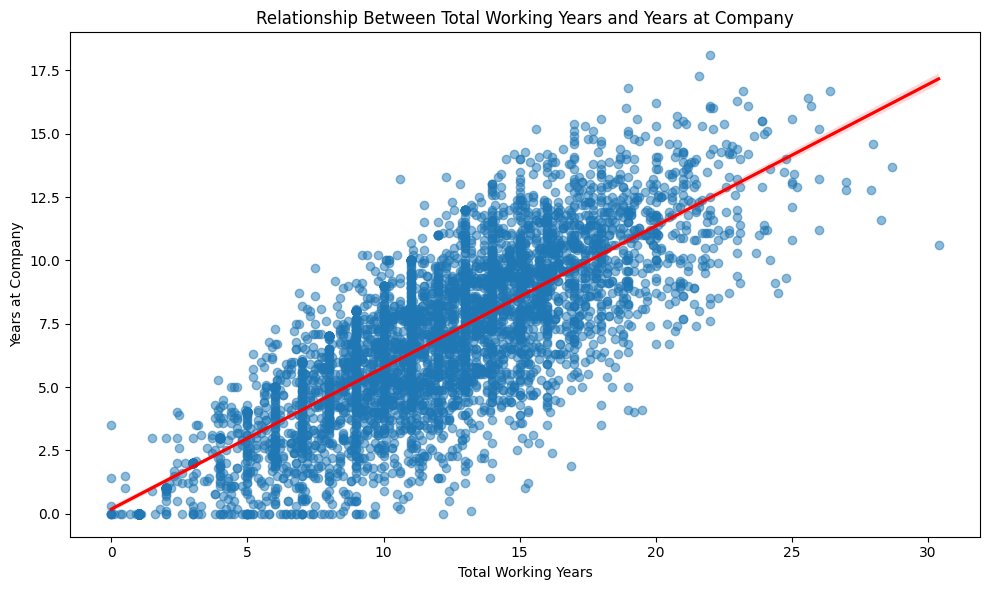

In [62]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='total_working_years',
    y='years_at_company',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title("Relationship Between Total Working Years and Years at Company")
plt.xlabel("Total Working Years")
plt.ylabel("Years at Company")

plt.tight_layout()
plt.show()

total working years vs age

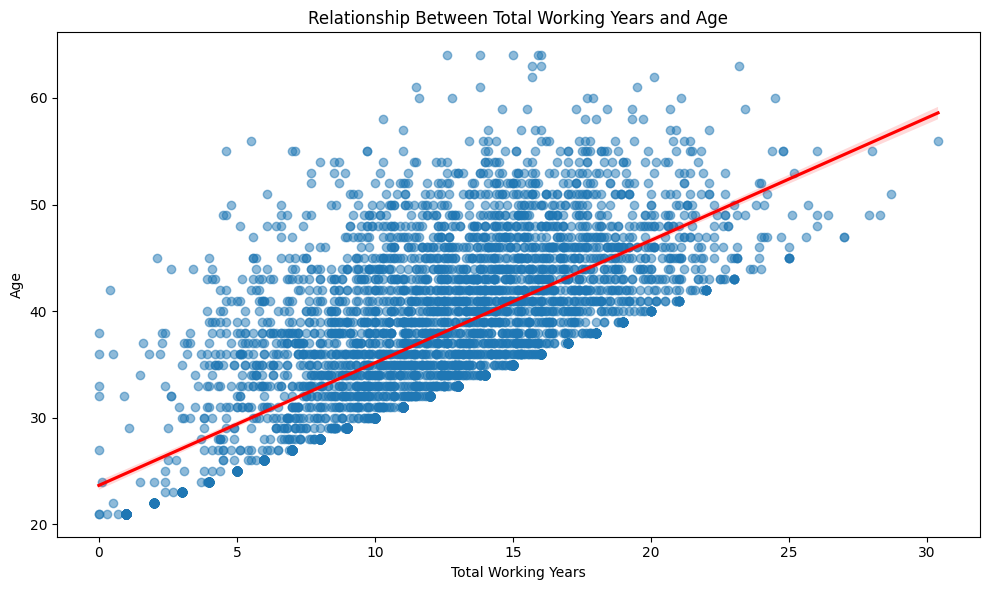

In [45]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='total_working_years',
    y='age',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title("Relationship Between Total Working Years and Age")
plt.xlabel("Total Working Years")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

monthly income vs year at company

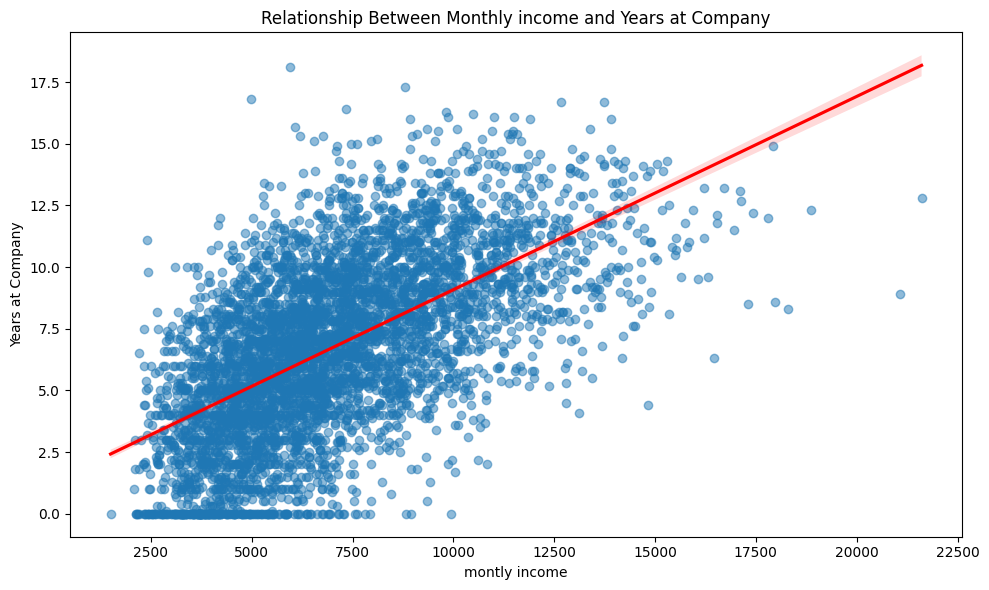

In [47]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='monthly_income',
    y='years_at_company',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title("Relationship Between Monthly income and Years at Company")
plt.xlabel("montly income")
plt.ylabel("Years at Company")

plt.tight_layout()
plt.show()

1 . gender wise attrition rate

,total_employees,attrition_count,attrition_rate
gender,,,
Female,2310,420,18.2
Male,2492,445,17.9
Non-binary,100,13,13.0


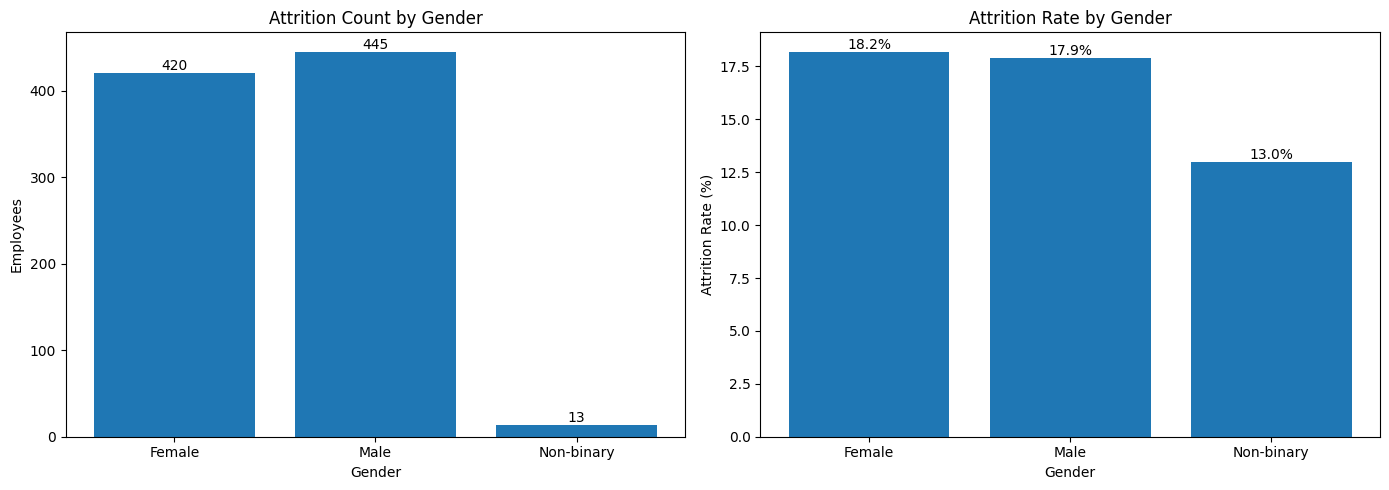

In [ ]:
gender_attrition = (
    df.groupby('gender')
      .agg(
          total_employees=('attrition', 'count'),
          attrition_count=('attrition', 'sum'),
          attrition_rate=('attrition', 'mean')
      )
)

gender_attrition['attrition_rate'] = (
    gender_attrition['attrition_rate'] * 100
).round(1)

display(gender_attrition)



fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Attrition Count

bars1 = ax[0].bar(
    gender_attrition.index,
    gender_attrition['attrition_count']
)

ax[0].set_title("Attrition Count by Gender")
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Employees")

# Data labels
for bar in bars1:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

# Attrition Rate
bars2 = ax[1].bar(
    gender_attrition.index,
    gender_attrition['attrition_rate']
)

ax[1].set_title("Attrition Rate by Gender")
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("Attrition Rate (%)")

# Data labels
for bar in bars2:
    height = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


**Male and female attrition rates are nearly identical (~18%), showing gender is not a primary driver of turnover in this dataset.**

burnout score and overtime_hours_per_week distribution across department

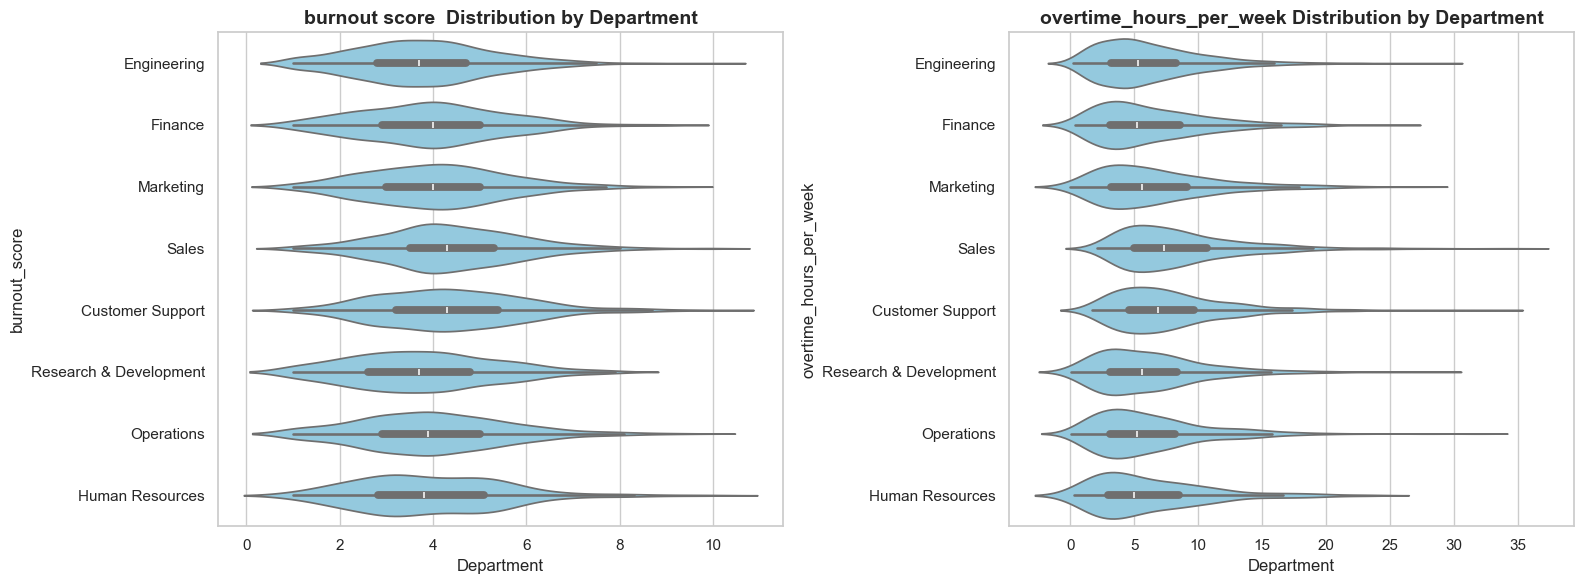

In [35]:
# Set style
sns.set_theme(style="whitegrid")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin Plot - burout score
sns.violinplot(
    data=df,
    x="burnout_score",
    y="department",
    color="skyblue",
    ax=axes[0]
)

axes[0].set_title("burnout score  Distribution by Department", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("burnout_score")

# Violin Plot - overtime_hours_per_week
sns.violinplot(
    data=df,
    x="overtime_hours_per_week",
    y="department",
    color="skyblue",
    ax=axes[1]
)

axes[1].set_title("overtime_hours_per_week Distribution by Department", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("overtime_hours_per_week")

# Improve spacing
plt.tight_layout()

plt.show()


**Sales and Customer Support show the highest median burnout (~4.3) and overtime (medians 7.4 and 6.9 hrs), while Engineering and R&D remain lowest.**

2. how monthly income and total_working_years spread across gender

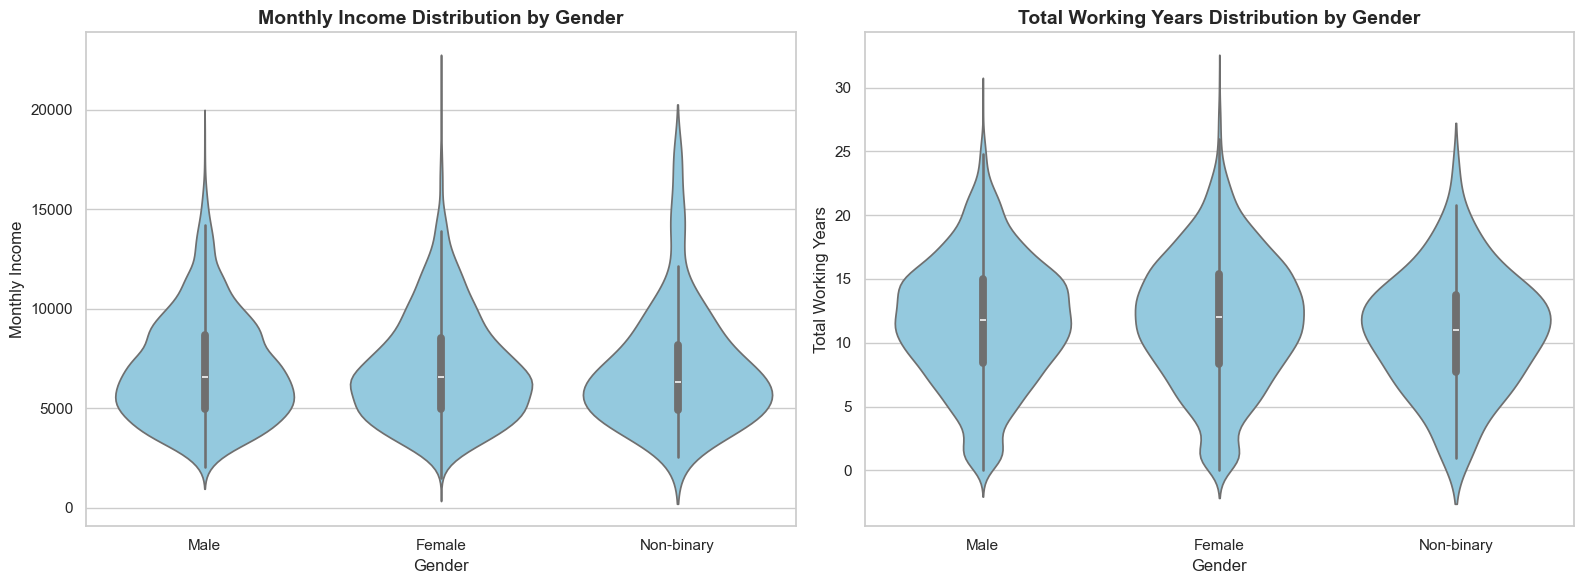

In [72]:
# Set style
sns.set_theme(style="whitegrid")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin Plot - Monthly Income
sns.violinplot(
    data=df,
    x="gender",
    y="monthly_income",
    color="skyblue",
    ax=axes[0]
)

axes[0].set_title("Monthly Income Distribution by Gender", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Monthly Income")

# Violin Plot - Total Working Years
sns.violinplot(
    data=df,
    x="gender",
    y="total_working_years",
    color="skyblue",
    ax=axes[1]
)

axes[1].set_title("Total Working Years Distribution by Gender", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Total Working Years")

# Improve spacing
plt.tight_layout()

plt.show()


**Monthly income and total working years show almost identical spreads across Male, Female, and Non-binary employees, indicating no meaningful gender-based disparity in compensation or experience levels in this organization.**

3 . department wise attrition rate 

,total_employees,attrition_count,attrition_rate
department,,,
Customer Support,628,150,23.9
Sales,810,162,20.0
Marketing,435,82,18.9
Finance,431,79,18.3
Human Resources,242,44,18.2
Operations,648,112,17.3
Engineering,1308,191,14.6
Research & Development,400,58,14.5


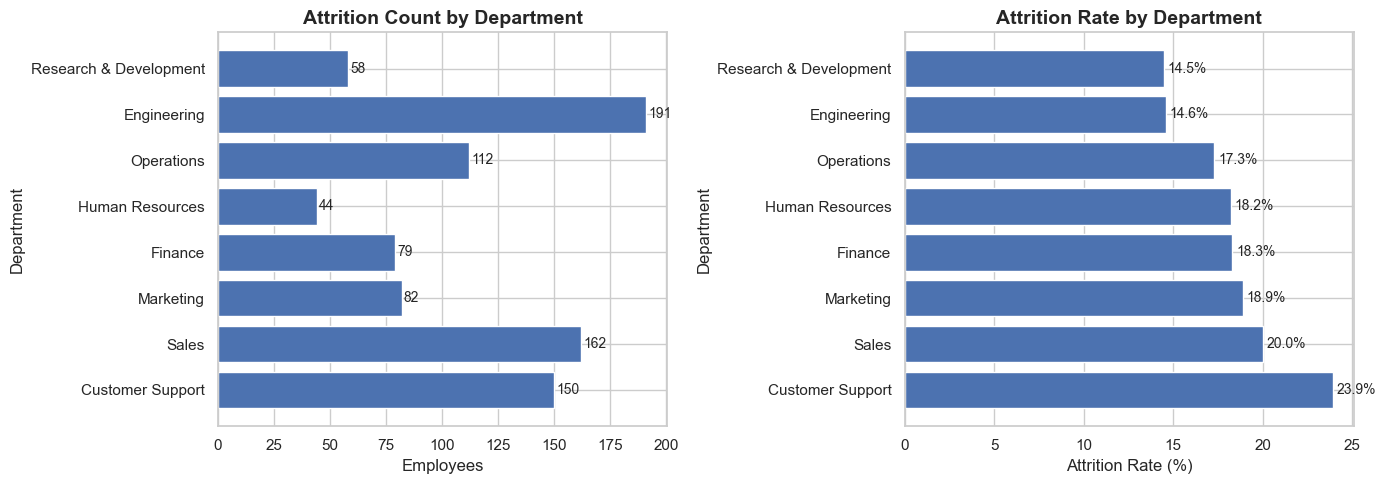

In [ ]:
department_attrition = (
    df.groupby('department')
      .agg(
          total_employees=('attrition', 'count'),
          attrition_count=('attrition', 'sum'),
          attrition_rate=('attrition', 'mean')
      )
)

department_attrition['attrition_rate'] = (
    department_attrition['attrition_rate'] * 100
).round(1)

department_attrition = department_attrition.sort_values(
    by="attrition_rate",
    ascending=False
)

display(department_attrition)



fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Attrition Count (Horizontal)
bars1 = ax[0].barh(
    department_attrition.index,
    department_attrition['attrition_count']
)

ax[0].set_title("Attrition Count by Department", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Employees")
ax[0].set_ylabel("Department")

# Data labels
for bar in bars1:
    width = bar.get_width()
    ax[0].text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )

# Attrition Rate (Horizontal)
bars2 = ax[1].barh(
    department_attrition.index,
    department_attrition['attrition_rate']
)

ax[1].set_title("Attrition Rate by Department", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Attrition Rate (%)")
ax[1].set_ylabel("Department")

# Data labels
for bar in bars2:
    width = bar.get_width()
    ax[1].text(
        width + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Customer Support shows the highest attrition (23.9%), followed by Sales (20%), while Engineering and R&D remain lowest (~14.5%). This mirrors real-world patterns where high customer-facing pressure and targets drive exits, unlike more stable technical roles.**

4 . engagement score spread across age group

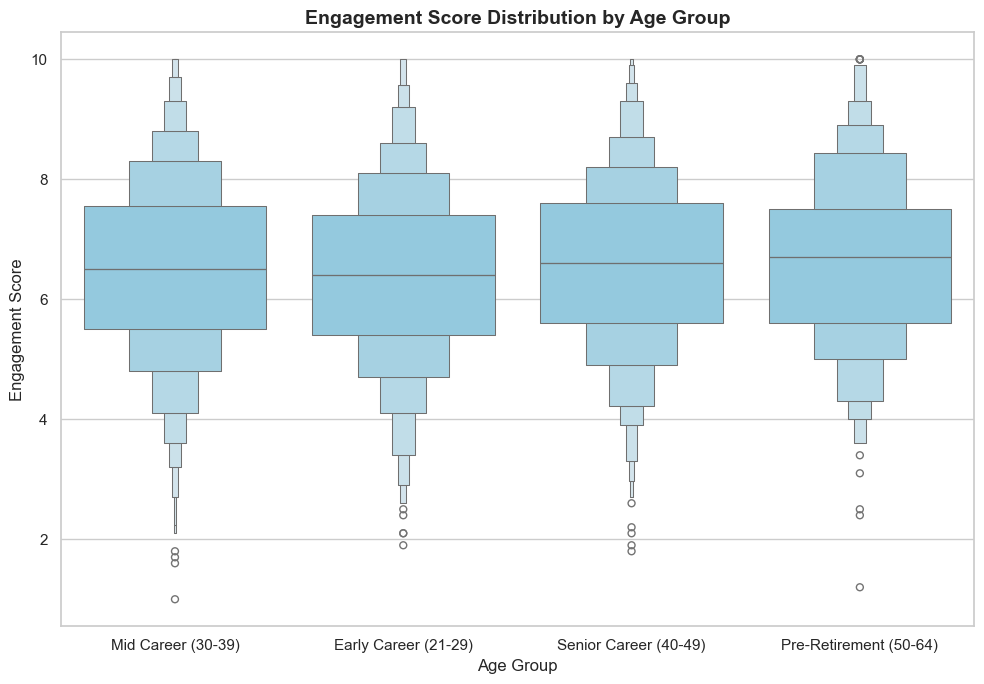

In [83]:
# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10, 7))

# Boxen plot
ax = sns.boxenplot(
    data=df,
    x="age_group",
    y="engagement_score",
    color="skyblue"
)

# Title & Labels
ax.set_title(
    "Engagement Score Distribution by Age Group",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Engagement Score", fontsize=12)

# Improve spacing
plt.tight_layout()

plt.show()


**Engagement scores remain fairly consistent across all age groups (means ~6.4–6.6), with only a mild upward shift in median for Pre-Retirement employees. Spread (IQR and overall range) is similar**

job level wise engament score

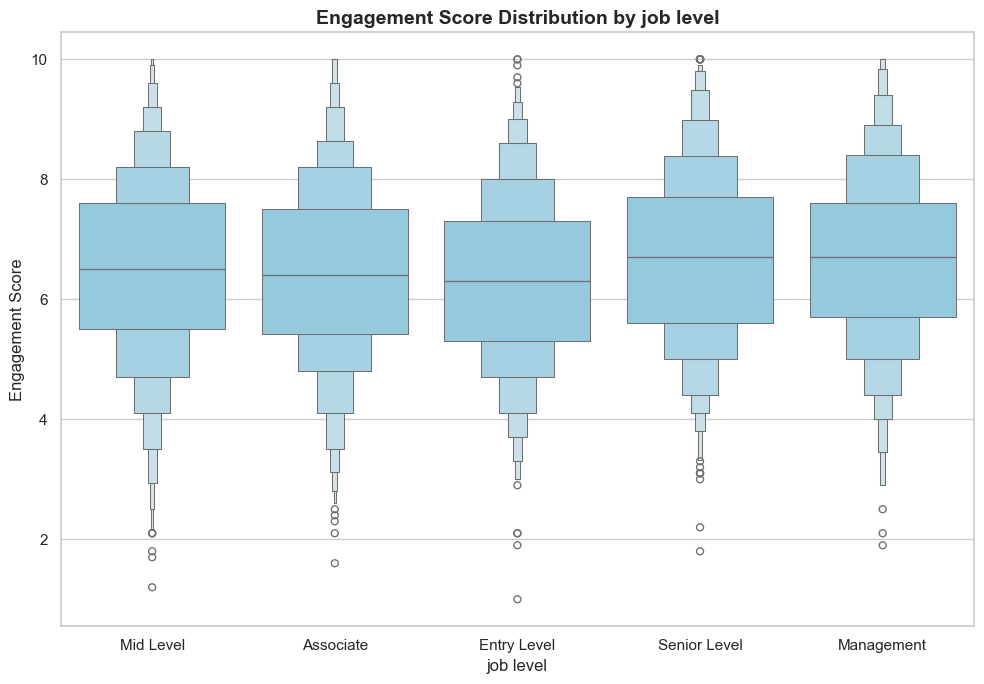

In [36]:
# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10, 7))

# Boxen plot
ax = sns.boxenplot(
    data=df,
    x="job_level",
    y="engagement_score",
    color="skyblue"
)

# Title & Labels
ax.set_title(
    "Engagement Score Distribution by job level",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("job level", fontsize=12)
ax.set_ylabel("Engagement Score", fontsize=12)

# Improve spacing
plt.tight_layout()

plt.show()

**Management and Senior Level employees show slightly higher median engagement (~6.7) than Entry Level (~6.3). Overall spread remains consistent, indicating job level has only a mild positive association with engagement.**

5 . job role wise salary hike pct 

,total_emp,avg_salary_hike_pct
job_role,,
HR Business Partner,80,12.66
Research Scientist,152,12.06
Data Engineer,314,11.98
Financial Analyst,141,11.80
Support Specialist,216,11.74
Marketing Specialist,145,11.69
Operations Analyst,212,11.65
Finance Manager,138,11.62
Engineering Manager,339,11.59


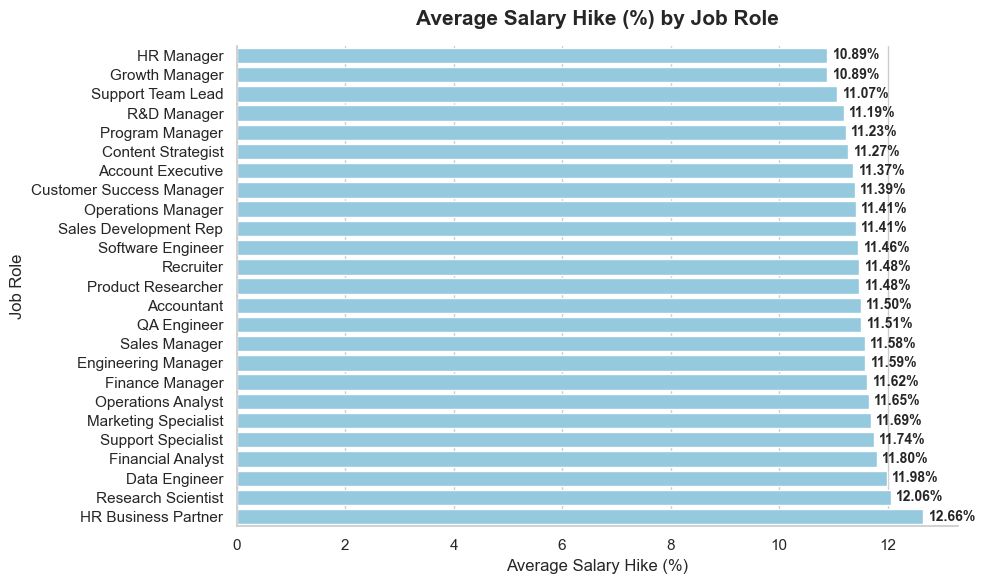

In [91]:
job_role_salary_hike = df.groupby('job_role').agg(
    total_emp = ('attrition' , 'count'),
    avg_salary_hike_pct = ('salary_hike_pct' , 'mean')
).round(2)

display(job_role_salary_hike.sort_values(by="avg_salary_hike_pct" , ascending=False))


# Sort data
plot_data = job_role_salary_hike.sort_values(
    by="avg_salary_hike_pct",
    ascending=True
)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10, 6))

# Horizontal bar chart
ax = sns.barplot(
    data=plot_data,
    x="avg_salary_hike_pct",
    y=plot_data.index,
    color="skyblue"
)

# Title & Labels
ax.set_title(
    "Average Salary Hike (%) by Job Role",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Average Salary Hike (%)", fontsize=12)
ax.set_ylabel("Job Role", fontsize=12)

# Add data labels
for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

# Remove top and right spines
sns.despine()

plt.tight_layout()
plt.show()

**HR Business Partner receives the highest average salary hike (12.66%), while Growth Manager and HR Manager have the lowest (~10.89%). Most roles cluster tightly around the overall mean of 11.51%, showing limited variation in hike distribution across job roles.**

6 . marital status wise attrition

,total_emp,total_attrition,attrition_rate
marital_status,,,
Divorced,533,99,18.6
Married,2337,422,18.1
Single,2032,357,17.6


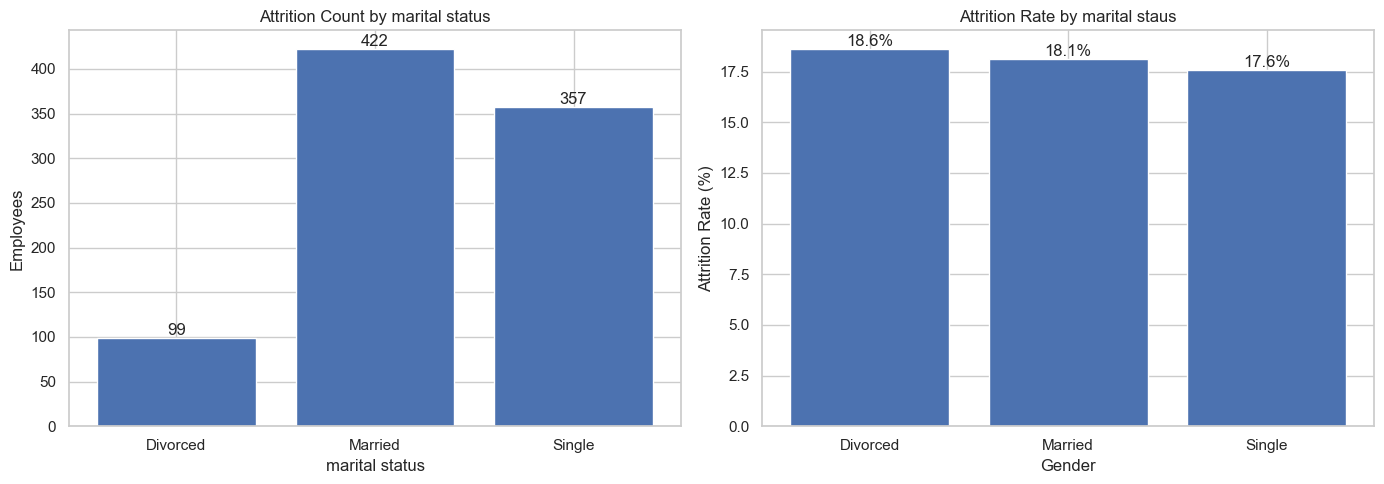

In [98]:
marital_status = (df.groupby('marital_status').agg(
    total_emp = ('attrition' , 'count'),
    total_attrition = ('attrition' , 'sum'),
    attrition_rate = ('attrition' , 'mean')
)
)

marital_status['attrition_rate'] = (
    marital_status['attrition_rate'] * 100
).round(1)

display(marital_status.round(2))



fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Attrition Count

bars1 = ax[0].bar(
    marital_status.index,
    marital_status['total_attrition']
)

ax[0].set_title("Attrition Count by marital status")
ax[0].set_xlabel("marital status")
ax[0].set_ylabel("Employees")

# Data labels
for bar in bars1:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

# Attrition Rate
bars2 = ax[1].bar(
    marital_status.index,
    marital_status['attrition_rate']
)

ax[1].set_title("Attrition Rate by marital staus")
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("Attrition Rate (%)")

# Data labels
for bar in bars2:
    height = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

**Attrition rates are nearly identical across marital statuses, with only a marginal difference of ~1%**

7 . how work life balance score spread between education level 

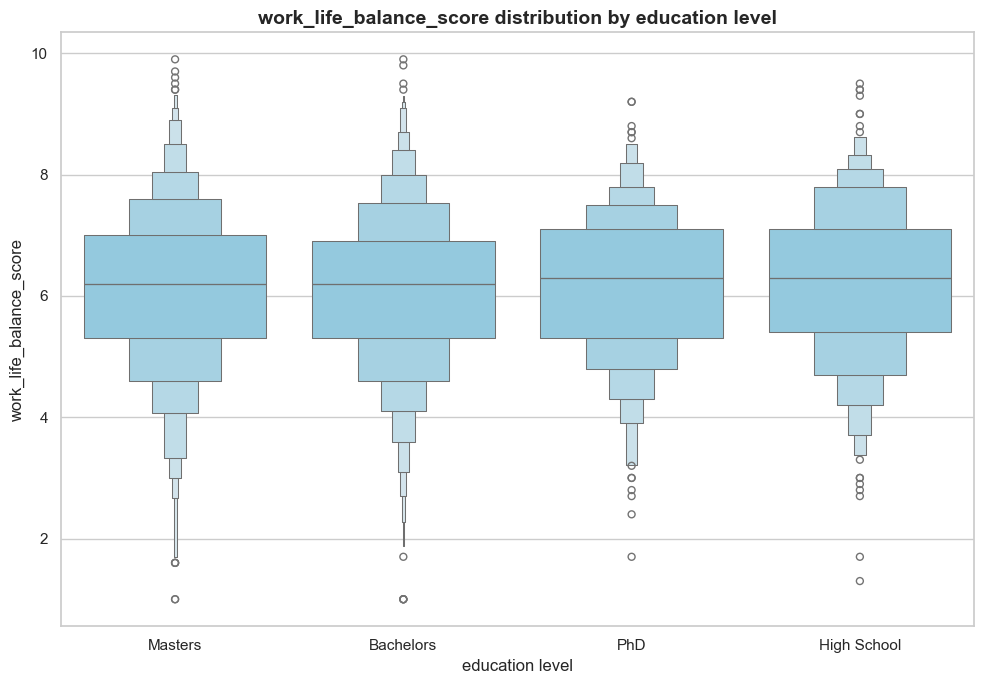

In [37]:
# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10, 7))

# Boxen plot
ax = sns.boxenplot(
    data=df,
    x="education_level",
    y="work_life_balance_score",
    color="skyblue"
)

# Title & Labels
ax.set_title(
    "work_life_balance_score distribution by education level",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("education level", fontsize=12)
ax.set_ylabel("work_life_balance_score", fontsize=12)

# Improve spacing
plt.tight_layout()

plt.show()

**Work-life balance scores are highly consistent across education levels (means ~6.11–6.23). High School employees show a marginally higher median, but overall education level has negligible impact on work-life balance perception.**

8 . how salary_hike_pct distributed across job_level

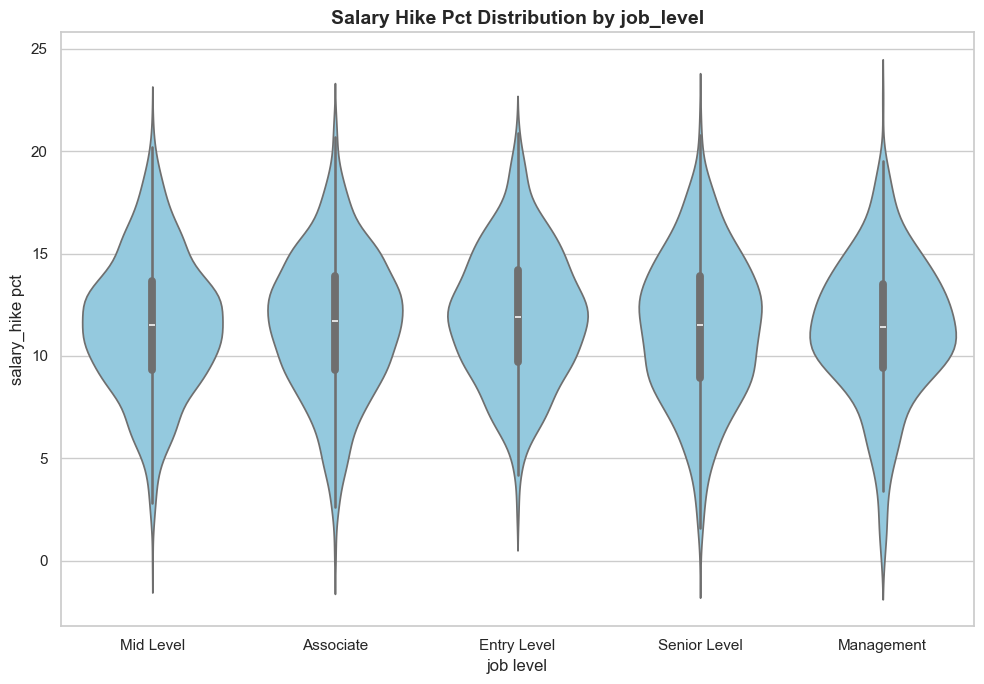

In [ ]:
# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10, 7))

# Boxen plot
ax = sns.violinplot(
    data=df,
    x="job_level",
    y="salary_hike_pct",
    color="skyblue"
)

# Title & Labels
ax.set_title(
    "Salary Hike Pct Distribution by job_level",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("job level", fontsize=12)
ax.set_ylabel("salary_hike pct", fontsize=12)

# Improve spacing
plt.tight_layout()

plt.show()

**Entry Level employees receive the highest average salary hike (11.94%), while Management has the lowest (11.28%). Overall differences are small, indicating salary hike policies are relatively uniform across job levels**

9 . job level wise avg monthly income and attrition distriution

,total_emp,avg_income,attritio,attrition_rate
job_level,,,,
Management,611,10781.40,94,15.0
Senior Level,930,8775.48,165,18.0
Mid Level,1422,7058.30,237,17.0
Associate,1354,5352.10,264,19.0
Entry Level,585,3819.48,118,20.0


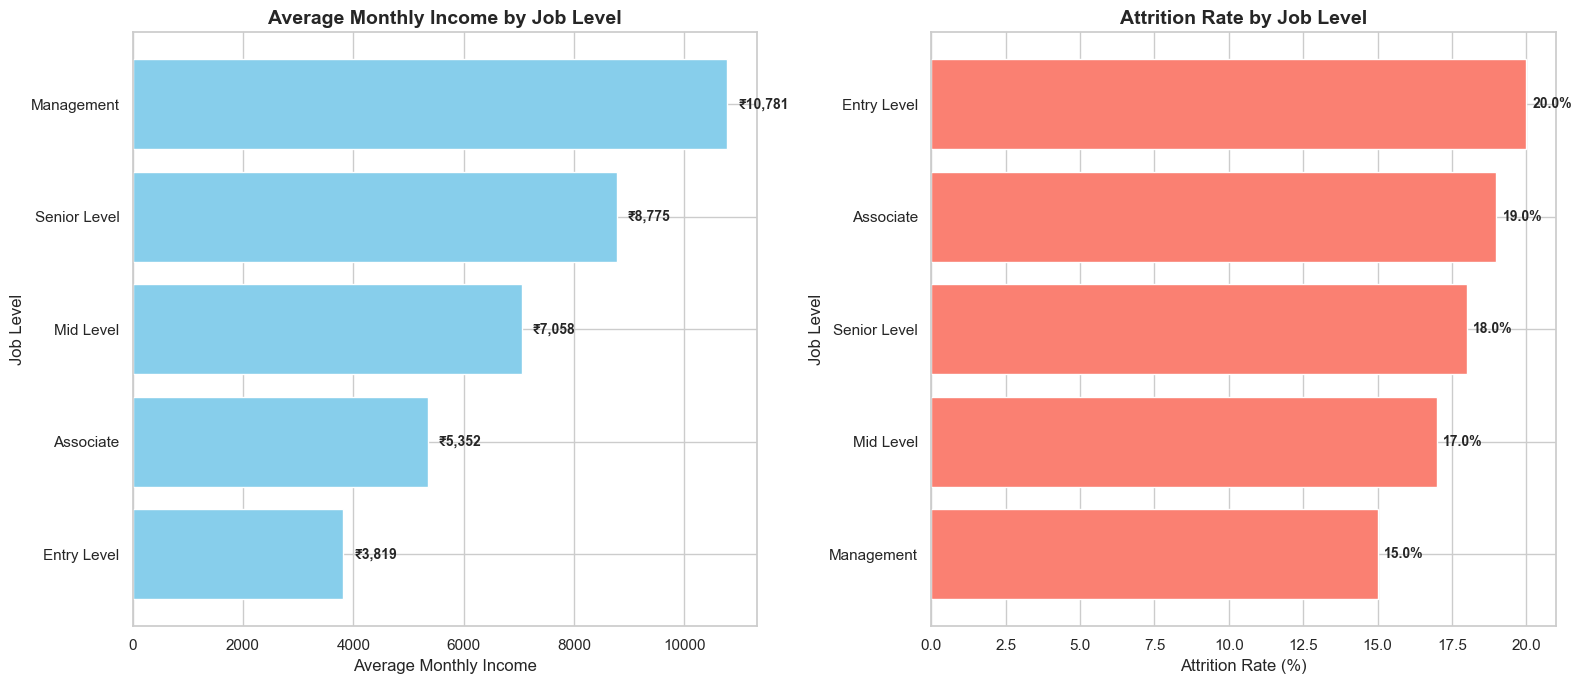

In [20]:
monthly_income = (
    df.groupby('job_level').agg(
        total_emp = ('attrition' , 'count'),
        avg_income = ('monthly_income' , 'mean'),
        attritio = ('attrition' , 'sum'),
        attrition_rate = ('attrition' , 'mean')
        )
).round(2)

monthly_income['attrition_rate'] = (monthly_income['attrition_rate'] * 100).round(1)
display(monthly_income.sort_values(by="avg_income" , ascending=False))


# Sort by average income
plot_data = monthly_income.sort_values(
    by="avg_income",
    ascending=True
)

# Set style
sns.set_theme(style="whitegrid")

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# 1. Average Monthly Income
bars1 = ax[0].barh(
    plot_data.index,
    plot_data["avg_income"],
    color="skyblue"
)

ax[0].set_title(
    "Average Monthly Income by Job Level",
    fontsize=14,
    fontweight="bold"
)
ax[0].set_xlabel("Average Monthly Income")
ax[0].set_ylabel("Job Level")

# Data labels
for bar in bars1:
    width = bar.get_width()
    ax[0].text(
        width + 200,
        bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )


# 2. Attrition Rate
plot_attrition = monthly_income.sort_values(
    by="attrition_rate",
    ascending=True
)

bars2 = ax[1].barh(
    plot_attrition.index,
    plot_attrition["attrition_rate"],
    color="salmon"
)

ax[1].set_title(
    "Attrition Rate by Job Level",
    fontsize=14,
    fontweight="bold"
)
ax[1].set_xlabel("Attrition Rate (%)")
ax[1].set_ylabel("Job Level")

# Data labels
for bar in bars2:
    width = bar.get_width()
    ax[1].text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Improve layout
plt.tight_layout()
plt.show()

**Management command significantly higher average income and show lower attrition. Entry-level roles have the highest attrition risk, highlighting the need for better early-career retention strategies.**

10 . workmode wise attration rate

,total_emp,total_attrition,attrition_rate,avg_monthly_income
work_mode,,,,
Hybrid,2188,367,17.0,7141.67
Onsite,1710,363,21.0,6914.01
Remote,1004,148,15.0,6790.58


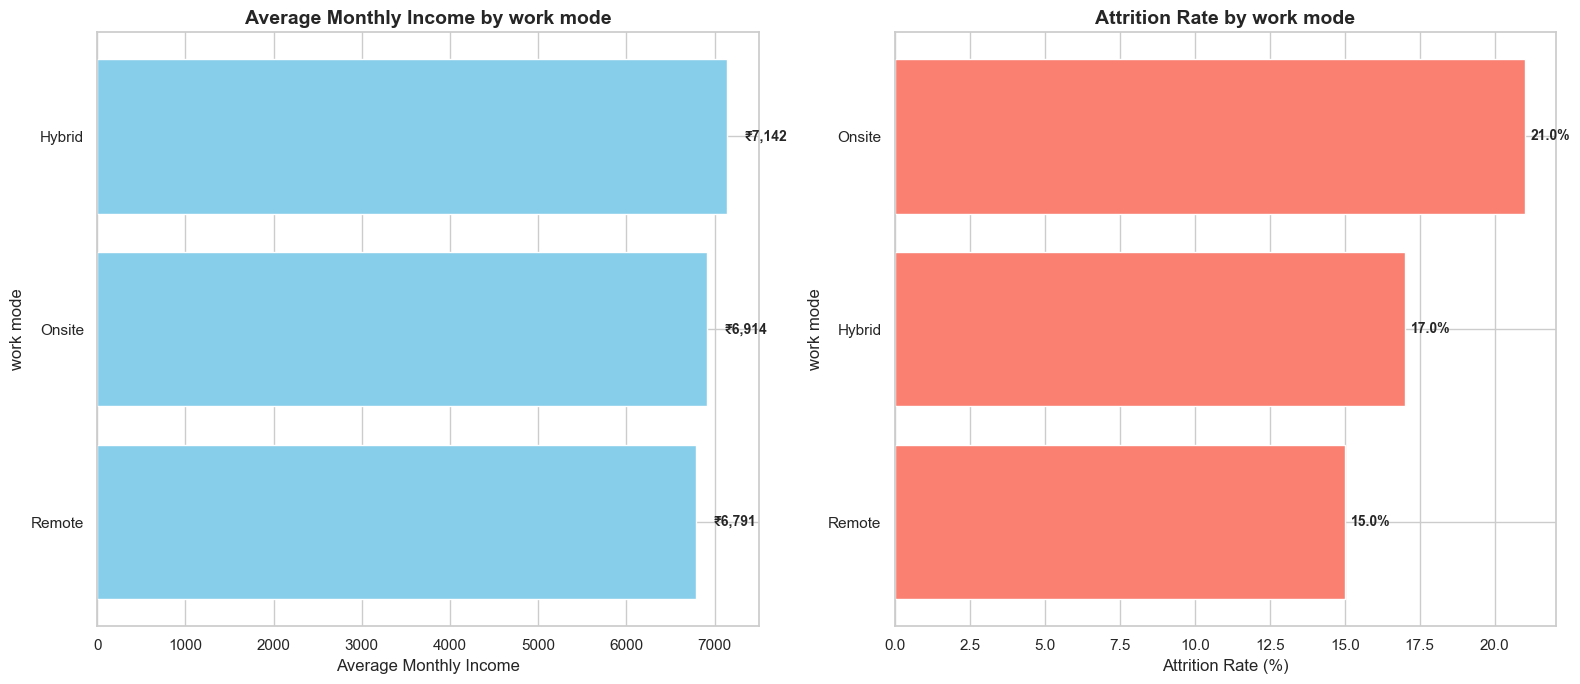

In [19]:
work_mode = df.groupby('work_mode').agg(
    total_emp = ('attrition' , 'count'),
    total_attrition = ('attrition' , 'sum'),
    attrition_rate = ('attrition' , 'mean'),
    avg_monthly_income = ('monthly_income' , 'mean')
).round(2)

work_mode['attrition_rate'] = (work_mode['attrition_rate'] * 100)
display(work_mode)

# Sort by average income
plot_data = work_mode.sort_values(
    by="avg_monthly_income",
    ascending=True
)

# Set style
sns.set_theme(style="whitegrid")

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# 1. Average Monthly Income
bars1 = ax[0].barh(
    plot_data.index,
    plot_data["avg_monthly_income"],
    color="skyblue"
)

ax[0].set_title(
    "Average Monthly Income by work mode",
    fontsize=14,
    fontweight="bold"
)
ax[0].set_xlabel("Average Monthly Income")
ax[0].set_ylabel("work mode")

# Data labels
for bar in bars1:
    width = bar.get_width()
    ax[0].text(
        width + 200,
        bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )


# 2. Attrition Rate
plot_attrition = work_mode.sort_values(
    by="attrition_rate",
    ascending=True
)

bars2 = ax[1].barh(
    plot_attrition.index,
    plot_attrition["attrition_rate"],
    color="salmon"
)

ax[1].set_title(
    "Attrition Rate by work mode",
    fontsize=14,
    fontweight="bold"
)
ax[1].set_xlabel("Attrition Rate (%)")
ax[1].set_ylabel("work mode")

# Data labels
for bar in bars2:
    width = bar.get_width()
    ax[1].text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Improve layout
plt.tight_layout()
plt.show()

**Onsite employees show the highest attrition rate (21%), followed by Hybrid (17%) and Remote (15%). Hybrid has the highest average monthly income.**

**Remote work is linked to the lowest attrition, while Onsite roles face the highest turnover. Flexible work arrangements appear to support better employee retention in this dataset.**

11 . perceived _ai_job risk distribution across job_role

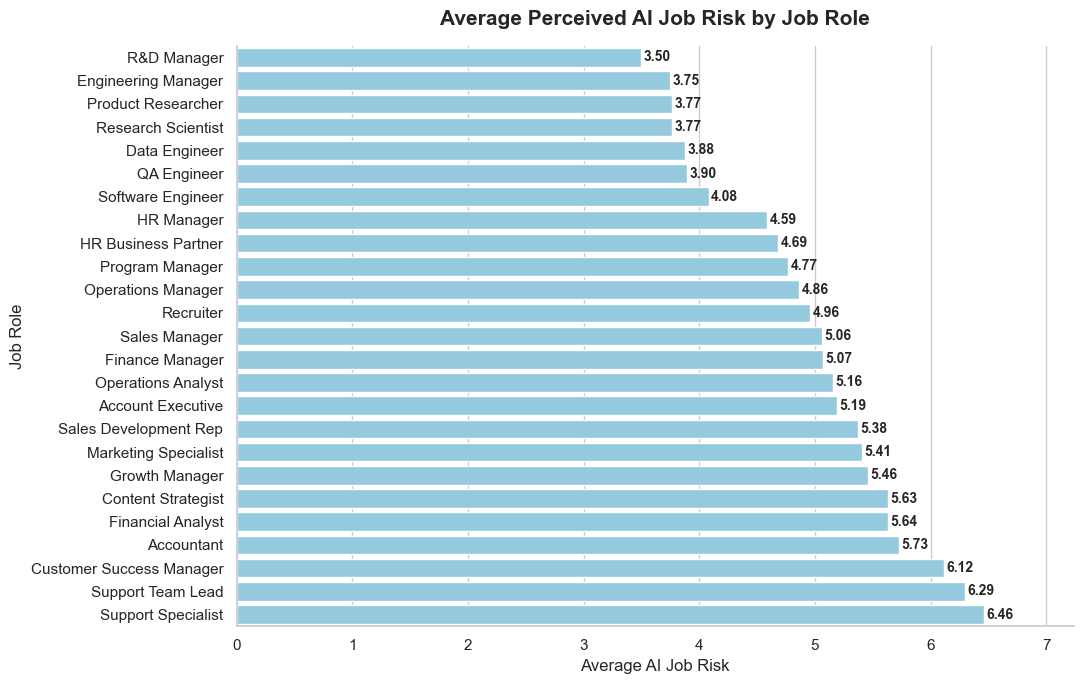

In [27]:
ai_job_risk = df.groupby('job_role').agg(
    total_emp = ('attrition' , 'count'),
    avg_ai_job_risk_num = ('perceived_ai_job_risk' , 'mean')
)
# display(ai_job_risk.round(2).sort_values(by='avg_ai_job_risk_num' , ascending=False))


# Sort for horizontal bar chart
plot_data = ai_job_risk.sort_values(
    by="avg_ai_job_risk_num",
    ascending=True
)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(11, 7))

# Horizontal bar chart
ax = sns.barplot(
    data=plot_data,
    x="avg_ai_job_risk_num",
    y=plot_data.index,
    color="skyblue"
)

# Title and labels
ax.set_title(
    "Average Perceived AI Job Risk by Job Role",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Average AI Job Risk", fontsize=12)
ax.set_ylabel("Job Role", fontsize=12)

# Add data labels
for bar in ax.patches:
    width = bar.get_width()

    ax.text(
        width + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Give labels some space
ax.set_xlim(
    0,
    plot_data["avg_ai_job_risk_num"].max() * 1.12
)

sns.despine()

plt.tight_layout()
plt.show()

**Support Specialist has the highest average perceived AI job risk (6.46), while R&D Manager has the lowest (3.50).**

**Customer-facing and support roles perceive significantly higher AI job risk than technical and R&D positions. This suggests frontline employees feel more vulnerable to automation compared to specialized technical roles.**

12 . how work life balance score distributed across gender 

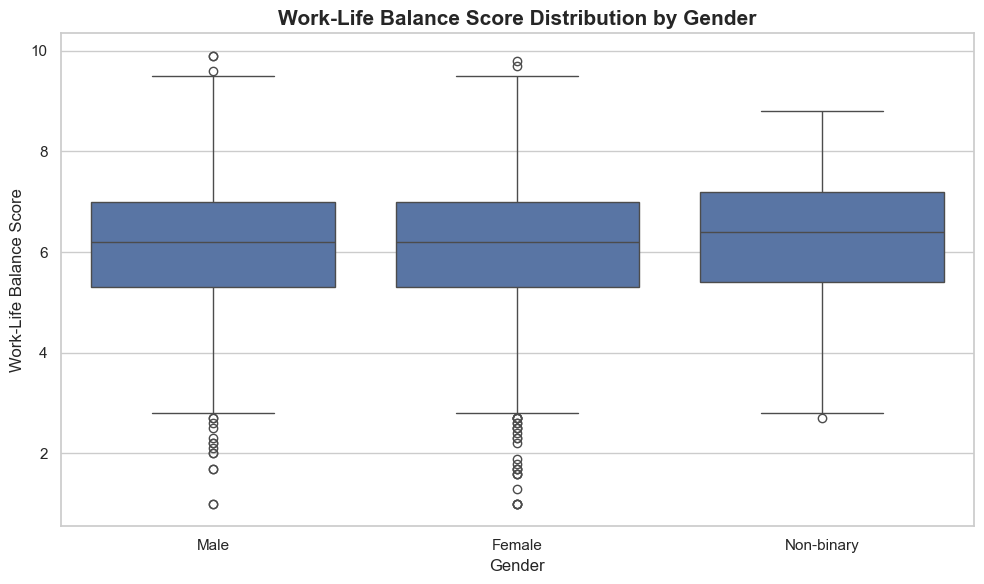

In [30]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df,
    x="gender",
    y="work_life_balance_score"
)

ax.set_title(
    "Work-Life Balance Score Distribution by Gender",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Gender")
ax.set_ylabel("Work-Life Balance Score")

plt.tight_layout()
plt.show()

**Work-life balance scores are nearly identical across genders (means ~6.12–6.21). Gender shows no meaningful difference in perceived work-life balance in this dataset.**

13 . uses_ai_tools_at_work and salary_hike_pct and attration rate

,total_emp,avg_salary_hike_pct,attrition_rate
uses_ai_tools_at_work,,,
True,2815,11.55,18.0
False,2087,11.47,18.0


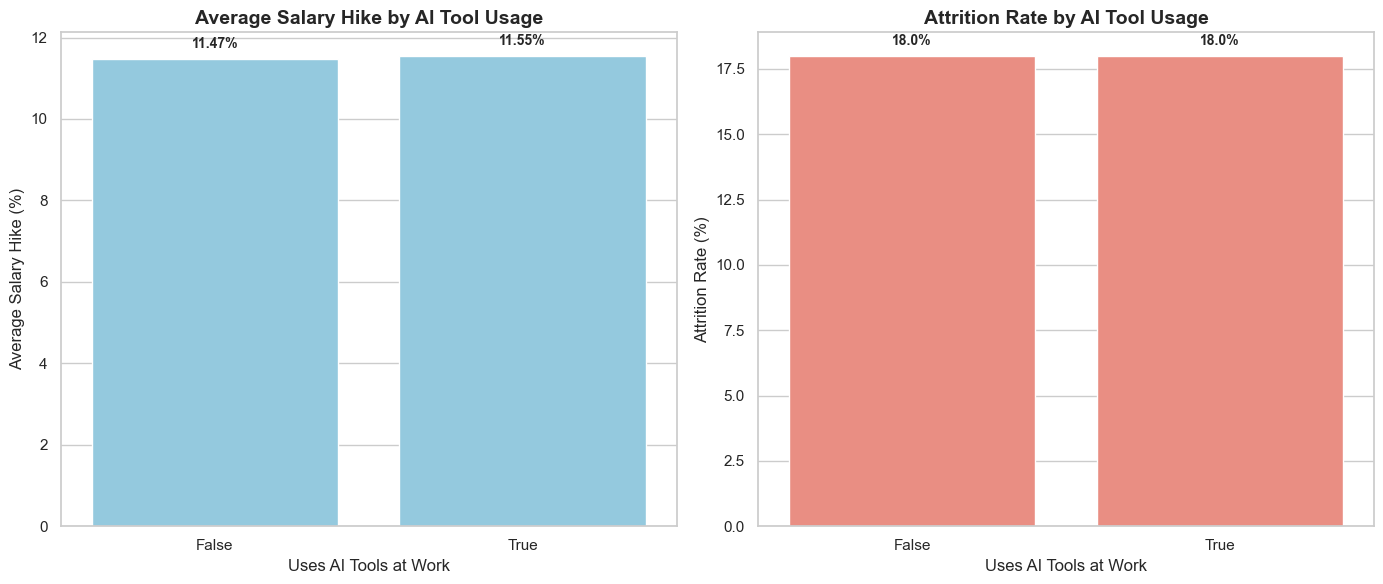

In [ ]:
use_ai_tool = df.groupby('uses_ai_tools_at_work').agg(
    total_emp = ('attrition' , 'count'),
    avg_salary_hike_pct = ('salary_hike_pct' , 'mean'),
    attrition_rate = ('attrition' , 'mean')
).round(2)

use_ai_tool['attrition_rate'] = (use_ai_tool['attrition_rate'] * 100).round(1)
display(use_ai_tool.sort_values(by="avg_salary_hike_pct" , ascending=False))


# Sort by average salary hike
plot_data = use_ai_tool.sort_values(
    by="avg_salary_hike_pct",
    ascending=False
)

# Set style
sns.set_theme(style="whitegrid")

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Average Salary Hike

bars1 = sns.barplot(
    data=plot_data,
    x=plot_data.index,
    y="avg_salary_hike_pct",
    color="skyblue",
    ax=ax[0]
)

ax[0].set_title(
    "Average Salary Hike by AI Tool Usage",
    fontsize=14,
    fontweight="bold"
)
ax[0].set_xlabel("Uses AI Tools at Work")
ax[0].set_ylabel("Average Salary Hike (%)")

# Data labels
for bar in bars1.patches:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# 2. Attrition Rate
bars2 = sns.barplot(
    data=plot_data,
    x=plot_data.index,
    y="attrition_rate",
    color="salmon",
    ax=ax[1]
)

ax[1].set_title(
    "Attrition Rate by AI Tool Usage",
    fontsize=14,
    fontweight="bold"
)
ax[1].set_xlabel("Uses AI Tools at Work")
ax[1].set_ylabel("Attrition Rate (%)")

# Data labels
for bar in bars2.patches:
    height = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Improve spacing
plt.tight_layout()
plt.show()

**Employees using AI tools have a slightly higher average salary hike (11.55% vs 11.47%), while attrition rate remains identical at 18% for both groups.**

**AI tool usage shows almost no difference in salary hikes and zero impact on attrition. It is not a significant driver of compensation or retention in this dataset.**